##### New train test split file after new preprocessing

In [6]:
import h5py
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report, cohen_kappa_score)
from sklearn.model_selection import RandomizedSearchCV
from sklearn.utils import resample
import time
from sklearn.model_selection import train_test_split

# -------------------- Sensitivity & Specificity --------------------
def sensitivity_score(y_true, y_pred):
    """Sensitivity = Recall for Sleep (positive class = 0)."""
    cm = confusion_matrix(y_true, y_pred)
    tp = cm[0, 0]
    fn = cm[0, 1]
    return tp / (tp + fn) if (tp + fn) > 0 else 0

def specificity_score(y_true, y_pred):
    """Specificity = Recall for Wake (negative class = 1)."""
    cm = confusion_matrix(y_true, y_pred)
    tn = cm[1, 1]
    fp = cm[1, 0]
    return tn / (tn + fp) if (tn + fp) > 0 else 0



# -------------------- Binary Random Forest classifier --------------------
def rf_classifier(X_train, y_train, X_test, y_test, use_scaling=False, **kwargs):
    print("\n--- Random Forest for Sleep vs Awake classification ---")
    
    # Optionally scale features (RF usually doesn't need scaling)
    if use_scaling:
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)
        print("Data scaled with StandardScaler.")
    else:
        X_train_scaled, X_test_scaled = X_train, X_test
        print("Data scaling skipped.")
    
    # Initialize Random Forest
    clf = RandomForestClassifier(class_weight='balanced', random_state=42, **kwargs)
    
    # Fit RF
    start_time = time.time()
    clf.fit(X_train_scaled, y_train)
    print(f"Random Forest fitted in {time.time() - start_time:.2f} seconds.")
    
    # Predict
    y_pred = clf.predict(X_test_scaled)
    
    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)  # recall for Wake (label=1)
    sensitivity = sensitivity_score(y_test, y_pred)          # Sleep
    specificity = specificity_score(y_test, y_pred)          # Wake
    f1 = f1_score(y_test, y_pred, zero_division=0)
    cohen_kappa = cohen_kappa_score(y_test, y_pred)
    
    print("\nEvaluation Metrics:")
    print(f"Accuracy:       {accuracy:.4f}")
    print(f"Precision:      {precision:.4f}")
    print(f"Recall (Wake):  {recall:.4f}")
    print(f"Sensitivity (Sleep): {sensitivity:.4f}")
    print(f"Specificity (Wake):  {specificity:.4f}")
    print(f"F1 Score:       {f1:.4f}")
    print(f"Cohen Kappa:    {cohen_kappa:.4f}")
    
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=['Sleep','Wake'], zero_division=0))
    
    return clf

# -------------------- RandomizedSearchCV for hyperparameter tuning --------------------
def tune_rf(X_train, y_train):
    print("\n🔍 Running Random Search for Random Forest Hyperparameter Tuning...")
    
    rf = RandomForestClassifier(class_weight='balanced', random_state=42)
    
    param_dist = {
        'n_estimators': [50, 100],
        'max_depth': [None, 5, 10],
        'min_samples_split': [2, 5],
        'min_samples_leaf': [1, 2],
        'max_features': ['sqrt', 'log2']
    }
    
    search = RandomizedSearchCV(
        rf,
        param_distributions=param_dist,
        n_iter=8,
        cv=3,
        scoring="f1_macro",
        verbose=1,
        n_jobs=-1,
        random_state=42
    )
    
    search.fit(X_train, y_train)
    
    print(f"\n✅ Best hyperparameters: {search.best_params_}")
    print(f"🏅 Best CV score (F1 macro): {search.best_score_:.4f}")
    
    return search.best_params_

# -------------------- Load HDF5 train/test split --------------------
hdf5_path = r"C:\Users\anita\OneDrive - Universitetet i Oslo\Masteroppgave zzz\UOslo_March2025\Combined\Step4_normalized_train_test_FINAL.h5"

with h5py.File(hdf5_path, 'r') as f:
    X_train = f['X_train'][:]
    X_test = f['X_test'][:]
    y_train = f['y_train'][:]
    y_test = f['y_test'][:]

# -------------------- New 80/20 train/test resplit! --------------------
X_all = np.concatenate([X_train, X_test], axis=0)
y_all = np.concatenate([y_train, y_test], axis=0)

X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all,
    test_size=0.2,
    random_state=42,
    stratify=y_all
)
print(f"Training samples: {X_train.shape[0]}, Test samples: {X_test.shape[0]}")


# -------------------- Filter unknown labels --------------------
valid_labels = [0,1,2,3,5]
train_idx = np.isin(y_train, valid_labels)
test_idx  = np.isin(y_test, valid_labels)

X_train = X_train[train_idx]
y_train = y_train[train_idx]
X_test  = X_test[test_idx]
y_test  = y_test[test_idx]

# -------------------- Map to binary: Sleep=0, Wake=1 --------------------
y_train_bin = np.copy(y_train)
y_test_bin  = np.copy(y_test)

sleep_stages = [1,2,3,5]
y_train_bin[np.isin(y_train_bin, sleep_stages)] = 0
y_test_bin[np.isin(y_test_bin, sleep_stages)] = 0

y_train_bin[y_train == 0] = 1
y_test_bin[y_test == 0] = 1

print("Unique train labels:", np.unique(y_train_bin, return_counts=True))
print("Unique test labels:", np.unique(y_test_bin, return_counts=True))

# -------------------- Upsample Wake --------------------
X_train_sleep = X_train[y_train_bin == 0]
y_train_sleep = y_train_bin[y_train_bin == 0]
X_train_wake = X_train[y_train_bin == 1]
y_train_wake = y_train_bin[y_train_bin == 1]

if len(X_train_sleep) > len(X_train_wake):
    X_wake_upsampled, y_wake_upsampled = resample(
        X_train_wake, y_train_wake,
        replace=True,
        n_samples=len(X_train_sleep),
        random_state=42
    )
    X_train_balanced = np.vstack([X_train_sleep, X_wake_upsampled])
    y_train_balanced = np.hstack([y_train_sleep, y_wake_upsampled])
else:
    X_train_balanced = np.vstack([X_train_sleep, X_train_wake])
    y_train_balanced = np.hstack([y_train_sleep, y_train_wake])

print(f"Balanced training set: {X_train_balanced.shape[0]} samples")



# -------------------- Run Random Search --------------------
best_params_binary = tune_rf(X_train_balanced, y_train_balanced)

# -------------------- Train final RF --------------------
rf_binary = rf_classifier(
    X_train_balanced, y_train_balanced,
    X_test, y_test_bin,
    **best_params_binary
)


Training samples: 46398, Test samples: 11600
Unique train labels: (array([0, 1]), array([38831,  7485]))
Unique test labels: (array([0, 1]), array([9708, 1872]))
Balanced training set: 77662 samples

🔍 Running Random Search for Random Forest Hyperparameter Tuning...
Fitting 3 folds for each of 8 candidates, totalling 24 fits

✅ Best hyperparameters: {'n_estimators': 50, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': None}
🏅 Best CV score (F1 macro): 0.9750

--- Random Forest for Sleep vs Awake classification ---
Data scaling skipped.
Random Forest fitted in 24.09 seconds.

Evaluation Metrics:
Accuracy:       0.9479
Precision:      0.8310
Recall (Wake):  0.8510
Sensitivity (Sleep): 0.9666
Specificity (Wake):  0.8510
F1 Score:       0.8409
Cohen Kappa:    0.8097

Classification Report:
              precision    recall  f1-score   support

       Sleep       0.97      0.97      0.97      9708
        Wake       0.83      0.85      0.84      1872

    

##### Test, no wake upsampling

Train labels: (array([0, 1]), array([38831,  7485]))

Running t-SNE...


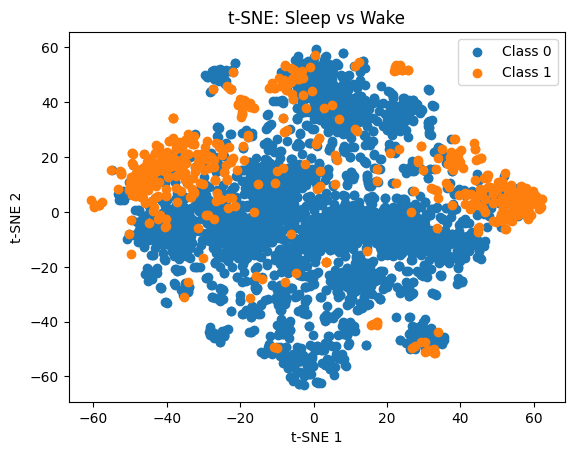


🔍 Running Random Search for RF tuning...

Best params: {'n_estimators': 50, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': None}
Best CV F1: 0.8999

--- Random Forest for Sleep vs Awake classification ---
Random Forest fitted in 24.52 seconds.

Evaluation Metrics:
Accuracy:       0.9467
Precision:      0.8676
Recall (Wake):  0.7911
Sensitivity (Sleep): 0.9767
Specificity (Wake):  0.7911
F1 Score:       0.8276
Cohen Kappa:    0.7962

Classification Report:
              precision    recall  f1-score   support

       Sleep       0.96      0.98      0.97      9708
        Wake       0.87      0.79      0.83      1872

    accuracy                           0.95     11580
   macro avg       0.91      0.88      0.90     11580
weighted avg       0.95      0.95      0.95     11580



In [4]:
import h5py
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report, cohen_kappa_score)
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import time

# -------------------- Sensitivity & Specificity --------------------
def sensitivity_score(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    tp = cm[0, 0]
    fn = cm[0, 1]
    return tp / (tp + fn) if (tp + fn) > 0 else 0

def specificity_score(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    tn = cm[1, 1]
    fp = cm[1, 0]
    return tn / (tn + fp) if (tn + fp) > 0 else 0

# -------------------- t-SNE Visualization --------------------
def plot_tsne(X, y, title="t-SNE Visualization", n_samples=3000):

    print("\nRunning t-SNE...")

    # Subsample for speed
    if len(X) > n_samples:
        idx = np.random.choice(len(X), n_samples, replace=False)
        X = X[idx]
        y = y[idx]

    # Scale data
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    tsne = TSNE(n_components=2, random_state=42, perplexity=30)
    X_embedded = tsne.fit_transform(X_scaled)

    plt.figure()

    for label in np.unique(y):
        plt.scatter(
            X_embedded[y == label, 0],
            X_embedded[y == label, 1],
            label=f"Class {label}"
        )

    plt.title(title)
    plt.xlabel("t-SNE 1")
    plt.ylabel("t-SNE 2")
    plt.legend()
    plt.show()

# -------------------- Random Forest classifier --------------------
def rf_classifier(X_train, y_train, X_test, y_test, use_scaling=False, **kwargs):
    print("\n--- Random Forest for Sleep vs Awake classification ---")
    
    if use_scaling:
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)

    clf = RandomForestClassifier(random_state=42, **kwargs)
    
    start_time = time.time()
    clf.fit(X_train, y_train)
    print(f"Random Forest fitted in {time.time() - start_time:.2f} seconds.")
    
    y_pred = clf.predict(X_test)
    
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    sensitivity = sensitivity_score(y_test, y_pred)
    specificity = specificity_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    kappa = cohen_kappa_score(y_test, y_pred)
    
    print("\nEvaluation Metrics:")
    print(f"Accuracy:       {accuracy:.4f}")
    print(f"Precision:      {precision:.4f}")
    print(f"Recall (Wake):  {recall:.4f}")
    print(f"Sensitivity (Sleep): {sensitivity:.4f}")
    print(f"Specificity (Wake):  {specificity:.4f}")
    print(f"F1 Score:       {f1:.4f}")
    print(f"Cohen Kappa:    {kappa:.4f}")
    
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=['Sleep','Wake'], zero_division=0))
    
    return clf

# -------------------- Hyperparameter tuning --------------------
def tune_rf(X_train, y_train):
    print("\n🔍 Running Random Search for RF tuning...")

    rf = RandomForestClassifier(random_state=42)

    param_dist = {
        'n_estimators': [50, 100],
        'max_depth': [None, 5, 10],
        'min_samples_split': [2, 5],
        'min_samples_leaf': [1, 2],
        'max_features': ['sqrt', 'log2']
    }

    search = RandomizedSearchCV(
        rf,
        param_distributions=param_dist,
        n_iter=8,
        cv=3,
        scoring="f1_macro",
        n_jobs=-1,
        random_state=42
    )

    search.fit(X_train, y_train)

    print(f"\nBest params: {search.best_params_}")
    print(f"Best CV F1: {search.best_score_:.4f}")

    return search.best_params_

# -------------------- Load Data --------------------
hdf5_path = r"C:\Users\anita\OneDrive - Universitetet i Oslo\Masteroppgave zzz\UOslo_March2025\Combined\Step4_normalized_train_test_FINAL.h5"

with h5py.File(hdf5_path, 'r') as f:
    X_train = f['X_train'][:]
    X_test = f['X_test'][:]
    y_train = f['y_train'][:]
    y_test = f['y_test'][:]

# -------------------- Re-split --------------------
X_all = np.concatenate([X_train, X_test], axis=0)
y_all = np.concatenate([y_train, y_test], axis=0)

X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all,
    test_size=0.2,
    random_state=42,
    stratify=y_all
)

# -------------------- Filter labels --------------------
valid_labels = [0,1,2,3,5]

train_idx = np.isin(y_train, valid_labels)
test_idx  = np.isin(y_test, valid_labels)

X_train = X_train[train_idx]
y_train = y_train[train_idx]
X_test  = X_test[test_idx]
y_test  = y_test[test_idx]

# -------------------- Binary mapping --------------------
y_train_bin = np.copy(y_train)
y_test_bin  = np.copy(y_test)

sleep_stages = [1,2,3,5]

y_train_bin[np.isin(y_train_bin, sleep_stages)] = 0
y_test_bin[np.isin(y_test_bin, sleep_stages)] = 0

y_train_bin[y_train == 0] = 1
y_test_bin[y_test == 0] = 1

print("Train labels:", np.unique(y_train_bin, return_counts=True))

# -------------------- t-SNE --------------------
plot_tsne(X_train, y_train_bin, title="t-SNE: Sleep vs Wake")

# -------------------- Train RF --------------------
best_params = tune_rf(X_train, y_train_bin)

rf_model = rf_classifier(
    X_train, y_train_bin,
    X_test, y_test_bin,
    **best_params
)

# Class imbalance: Smote

In [3]:
# ================================
# Random Forest Sleep vs Wake
# SMOTE Oversampling (Wake)
# ================================

import h5py
import numpy as np
from collections import Counter

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    cohen_kappa_score
)

from imblearn.over_sampling import SMOTE

def sensitivity_score(y_true, y_pred):
    """Sensitivity = Recall for Sleep (positive class = 0)."""
    cm = confusion_matrix(y_true, y_pred)
    tp = cm[0, 0]
    fn = cm[0, 1]
    return tp / (tp + fn) if (tp + fn) > 0 else 0

def specificity_score(y_true, y_pred):
    """Specificity = Recall for Wake (negative class = 1)."""
    cm = confusion_matrix(y_true, y_pred)
    tn = cm[1, 1]
    fp = cm[1, 0]
    return tn / (tn + fp) if (tn + fp) > 0 else 0

# -------------------- Load HDF5 data --------------------
hdf5_path = r"C:\Users\anita\OneDrive - Universitetet i Oslo\Masteroppgave zzz\UOslo_March2025\Combined\Step4_normalized_train_test_FINAL.h5"

with h5py.File(hdf5_path, 'r') as f:
    X_train_old = f['X_train'][:]
    X_test_old  = f['X_test'][:]
    y_train_old = f['y_train'][:]
    y_test_old  = f['y_test'][:]

# -------------------- Combine and split 80/20 --------------------
X_all = np.concatenate([X_train_old, X_test_old], axis=0)
y_all = np.concatenate([y_train_old, y_test_old], axis=0)

X_train, X_test, y_train, y_test = train_test_split(
    X_all,
    y_all,
    test_size=0.2,
    random_state=42,
    stratify=y_all
)

print(f"Training samples: {X_train.shape[0]}")
print(f"Test samples:     {X_test.shape[0]}")

# -------------------- Binary mapping: Sleep=0, Wake=1 --------------------
sleep_stages = [1, 2, 3, 5]
y_train_bin = np.where(np.isin(y_train, sleep_stages), 0, 1)
y_test_bin  = np.where(np.isin(y_test, sleep_stages), 0, 1)

print("\nClass distribution BEFORE SMOTE:")
print("Train:", Counter(y_train_bin))
print("Test: ", Counter(y_test_bin))

# -------------------- SMOTE Oversampling --------------------
# Partial oversampling (Wake minority class)
smote = SMOTE(
    sampling_strategy=0.34,  # Wake = 34% of Sleep (adjustable)
    k_neighbors=5,
    random_state=42
)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train_bin)

print("\nClass distribution AFTER SMOTE:")
print("Train:", Counter(y_train_smote))

# -------------------- Random Forest --------------------
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features="log2",
    class_weight={0: 1, 1: 4},  # give more weight to Wake
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_smote, y_train_smote)

# -------------------- Predict on TEST --------------------
y_pred = rf.predict(X_test)

# -------------------- Metrics --------------------
accuracy = accuracy_score(y_test_bin, y_pred)
precision = precision_score(y_test_bin, y_pred, zero_division=0)
recall = recall_score(y_test_bin, y_pred, zero_division=0)
sensitivity = sensitivity_score(y_test_bin, y_pred)          # Sleep
specificity = specificity_score(y_test_bin, y_pred)   
f1 = f1_score(y_test_bin, y_pred, zero_division=0)
cohen_kappa = cohen_kappa_score(y_test_bin, y_pred)

cm = confusion_matrix(y_test_bin, y_pred)
sleep_recall = cm[0, 0] / (cm[0, 0] + cm[0, 1])
wake_recall  = cm[1, 1] / (cm[1, 1] + cm[1, 0])

print("\nEvaluation Metrics:") #TEST
print(f"Accuracy:              {accuracy:.4f}")
print(f"Precision (Wake):      {precision:.4f}")
print(f"Recall (Wake):         {recall:.4f}")
print(f"Sensitivity (Sleep):   {sleep_recall:.4f}")
print(f"Specificity (Wake):    {wake_recall:.4f}")
print(f"F1 Score:              {f1:.4f}")
print(f"Cohen Kappa:           {cohen_kappa:.4f}")


print("\nClassification Report:")
print(
    classification_report(
        y_test_bin,
        y_pred,
        target_names=["Sleep", "Wake"],
        zero_division=0
    )
)




Training samples: 46398
Test samples:     11600

Class distribution BEFORE SMOTE:
Train: Counter({np.int64(0): 38831, np.int64(1): 7567})
Test:  Counter({np.int64(0): 9708, np.int64(1): 1892})

Class distribution AFTER SMOTE:
Train: Counter({np.int64(0): 38831, np.int64(1): 13202})

Evaluation Metrics:
Accuracy:              0.9466
Precision (Wake):      0.8561
Recall (Wake):         0.8081
Sensitivity (Sleep):   0.9735
Specificity (Wake):    0.8081
F1 Score:              0.8314
Cohen Kappa:           0.7997

Classification Report:
              precision    recall  f1-score   support

       Sleep       0.96      0.97      0.97      9708
        Wake       0.86      0.81      0.83      1892

    accuracy                           0.95     11600
   macro avg       0.91      0.89      0.90     11600
weighted avg       0.95      0.95      0.95     11600



### Adasyn

In [1]:
# ================================
# Random Forest Sleep vs Wake
# ADASYN Oversampling (Wake)
# ================================

import h5py
import numpy as np
from collections import Counter

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    cohen_kappa_score
)

from imblearn.over_sampling import ADASYN

def sensitivity_score(y_true, y_pred):
    """Sensitivity = Recall for Sleep (positive class = 0)."""
    cm = confusion_matrix(y_true, y_pred)
    tp = cm[0, 0]
    fn = cm[0, 1]
    return tp / (tp + fn) if (tp + fn) > 0 else 0

def specificity_score(y_true, y_pred):
    """Specificity = Recall for Wake (negative class = 1)."""
    cm = confusion_matrix(y_true, y_pred)
    tn = cm[1, 1]
    fp = cm[1, 0]
    return tn / (tn + fp) if (tn + fp) > 0 else 0

# -------------------- Load HDF5 data --------------------
hdf5_path = r"C:\Users\anita\OneDrive - Universitetet i Oslo\Masteroppgave zzz\UOslo_March2025\Combined\Step4_normalized_train_test_FINAL.h5"

with h5py.File(hdf5_path, 'r') as f:
    X_train_old = f['X_train'][:]
    X_test_old  = f['X_test'][:]
    y_train_old = f['y_train'][:]
    y_test_old  = f['y_test'][:]

# -------------------- Combine and split 80/20 --------------------
X_all = np.concatenate([X_train_old, X_test_old], axis=0)
y_all = np.concatenate([y_train_old, y_test_old], axis=0)

X_train, X_test, y_train, y_test = train_test_split(
    X_all,
    y_all,
    test_size=0.2,
    random_state=42,
    stratify=y_all
)

print(f"Training samples: {X_train.shape[0]}")
print(f"Test samples:     {X_test.shape[0]}")

# -------------------- Binary mapping: Sleep=0, Wake=1 --------------------
sleep_stages = [1, 2, 3, 5]
y_train_bin = np.where(np.isin(y_train, sleep_stages), 0, 1)
y_test_bin  = np.where(np.isin(y_test, sleep_stages), 0, 1)

print("\nClass distribution BEFORE ADASYN:")
print("Train:", Counter(y_train_bin))
print("Test: ", Counter(y_test_bin))

# -------------------- ADASYN Oversampling --------------------
# ADASYN adaptively generates more samples in harder-to-learn regions
# sampling_strategy: desired ratio of minority/majority after resampling
adasyn = ADASYN(
    sampling_strategy=0.34,  # Wake = 34% of Sleep (adjustable)
    n_neighbors=5,           # note: ADASYN uses n_neighbors, not k_neighbors
    random_state=42
)

X_train_adasyn, y_train_adasyn = adasyn.fit_resample(X_train, y_train_bin)

print("\nClass distribution AFTER ADASYN:")
print("Train:", Counter(y_train_adasyn))

# -------------------- Random Forest --------------------
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features="log2",
    class_weight={0: 1, 1: 4},  # give more weight to Wake
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_adasyn, y_train_adasyn)

# -------------------- Predict on TEST --------------------
y_pred = rf.predict(X_test)

# -------------------- Metrics --------------------
accuracy    = accuracy_score(y_test_bin, y_pred)
precision   = precision_score(y_test_bin, y_pred, zero_division=0)
recall      = recall_score(y_test_bin, y_pred, zero_division=0)
sensitivity = sensitivity_score(y_test_bin, y_pred)
specificity = specificity_score(y_test_bin, y_pred)
f1          = f1_score(y_test_bin, y_pred, zero_division=0)
cohen_kappa = cohen_kappa_score(y_test_bin, y_pred)

cm = confusion_matrix(y_test_bin, y_pred)
sleep_recall = cm[0, 0] / (cm[0, 0] + cm[0, 1])
wake_recall  = cm[1, 1] / (cm[1, 1] + cm[1, 0])

print("\nEvaluation Metrics:")
print(f"Accuracy:              {accuracy:.4f}")
print(f"Precision (Wake):      {precision:.4f}")
print(f"Recall (Wake):         {recall:.4f}")
print(f"Sensitivity (Sleep):   {sleep_recall:.4f}")
print(f"Specificity (Wake):    {wake_recall:.4f}")
print(f"F1 Score:              {f1:.4f}")
print(f"Cohen Kappa:           {cohen_kappa:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_test_bin,
        y_pred,
        target_names=["Sleep", "Wake"],
        zero_division=0
    )
)

Training samples: 46398
Test samples:     11600

Class distribution BEFORE ADASYN:
Train: Counter({np.int64(0): 38831, np.int64(1): 7567})
Test:  Counter({np.int64(0): 9708, np.int64(1): 1892})

Class distribution AFTER ADASYN:
Train: Counter({np.int64(0): 38831, np.int64(1): 14320})

Evaluation Metrics:
Accuracy:              0.9475
Precision (Wake):      0.8418
Recall (Wake):         0.8351
Sensitivity (Sleep):   0.9694
Specificity (Wake):    0.8351
F1 Score:              0.8384
Cohen Kappa:           0.8071

Classification Report:
              precision    recall  f1-score   support

       Sleep       0.97      0.97      0.97      9708
        Wake       0.84      0.84      0.84      1892

    accuracy                           0.95     11600
   macro avg       0.90      0.90      0.90     11600
weighted avg       0.95      0.95      0.95     11600



### Test 2 (Add N)

In [1]:
# ================================
# Random Forest Sleep vs Wake
# Full SMOTE Implementation (1:1 balance)
# ================================

import h5py
import numpy as np
from collections import Counter
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    cohen_kappa_score
)
from sklearn.neighbors import NearestNeighbors

# -------------------- Load HDF5 data --------------------
hdf5_path = r"C:\Users\anita\OneDrive - Universitetet i Oslo\Masteroppgave zzz\UOslo_March2025\Combined\Step4_normalized_train_test_FINAL.h5"

with h5py.File(hdf5_path, 'r') as f:
    X_train_old = f['X_train'][:]
    X_test_old  = f['X_test'][:]
    y_train_old = f['y_train'][:]
    y_test_old  = f['y_test'][:]

# -------------------- New 80/20 split --------------------
X_all = np.concatenate([X_train_old, X_test_old], axis=0)
y_all = np.concatenate([y_train_old, y_test_old], axis=0)

X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all,
    test_size=0.2,
    random_state=42,
    stratify=y_all
)

# -------------------- Binary mapping: Sleep=0, Wake=1 --------------------
sleep_stages = [1, 2, 3, 5]
y_train_bin = np.where(np.isin(y_train, sleep_stages), 0, 1)
y_test_bin  = np.where(np.isin(y_test, sleep_stages), 0, 1)

print("\nClass distribution BEFORE SMOTE:")
print("Train:", Counter(y_train_bin))
print("Test: ", Counter(y_test_bin))

# -------------------- Full SMOTE --------------------
def full_smote(X, y, minority_class=1, k=5, random_state=42):
    """
    Implements full SMOTE to reach 1:1 class balance.
    Steps:
    1. Compute number of synthetic samples N = majority - minority
    2. Randomly pick a minority sample
    3. Find k nearest neighbors of that sample (minority only)
    4. Randomly pick one neighbor and interpolate
    5. Repeat until N synthetic samples are generated
    """
    np.random.seed(random_state)
    
    # Minority samples
    X_min = X[y == minority_class]
    n_min = X_min.shape[0]
    
    # Majority samples
    n_maj = X[y != minority_class].shape[0]
    
    # N = number of synthetic samples needed
    N = n_maj - n_min
    if N <= 0:
        return X, y  # already balanced
    
    # Fit NearestNeighbors on minority samples
    nn = NearestNeighbors(n_neighbors=min(k, n_min)).fit(X_min)
    
    synthetic_samples = []
    
    for _ in range(N):
        # Step 1: Random minority sample
        idx = np.random.randint(0, n_min)
        x_i = X_min[idx].reshape(1, -1)
        
        # Step 2: k nearest neighbors
        neighbors = nn.kneighbors(x_i, return_distance=False)[0]
        
        # Step 3: pick one neighbor randomly
        nn_idx = np.random.choice(neighbors)
        x_nn = X_min[nn_idx]
        
        # Interpolation
        gap = np.random.rand()
        synthetic = x_i.flatten() + gap * (x_nn - x_i.flatten())
        synthetic_samples.append(synthetic)
    
    X_synth = np.array(synthetic_samples)
    y_synth = np.array([minority_class]*N)
    
    # Combine original + synthetic
    X_new = np.vstack([X, X_synth])
    y_new = np.hstack([y, y_synth])
    
    return X_new, y_new

# Apply full SMOTE to balance Sleep/Wake
X_train_smote, y_train_smote = full_smote(X_train, y_train_bin, minority_class=1, k=5)

print("\nClass distribution AFTER full SMOTE:")
print("Train:", Counter(y_train_smote))

# -------------------- Random Forest --------------------
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features="log2",
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_smote, y_train_smote)

# -------------------- Prediction --------------------
y_pred = rf.predict(X_test)


# -------------------- Metrics --------------------
accuracy = accuracy_score(y_test_bin, y_pred)
precision = precision_score(y_test_bin, y_pred, zero_division=0)
recall = recall_score(y_test_bin, y_pred, zero_division=0)
f1 = f1_score(y_test_bin, y_pred, zero_division=0)
cohen_kappa = cohen_kappa_score(y_test_bin, y_pred)

cm = confusion_matrix(y_test_bin, y_pred)
sleep_recall = cm[0,0] / (cm[0,0] + cm[0,1])
wake_recall  = cm[1,1] / (cm[1,1] + cm[1,0])

print("\nEvaluation Metrics:")
print(f"Accuracy:              {accuracy:.4f}")
print(f"Precision (Wake):      {precision:.4f}")
print(f"Recall (Wake):         {recall:.4f}")
print(f"Sensitivity (Sleep):   {sleep_recall:.4f}")
print(f"Specificity (Wake):    {wake_recall:.4f}")
print(f"F1 Score:              {f1:.4f}")
print(f"Cohen Kappa:           {cohen_kappa:.4f}")

print("\nClassification Report:")
print(classification_report(y_test_bin, y_pred, target_names=["Sleep", "Wake"], zero_division=0))



Class distribution BEFORE SMOTE:
Train: Counter({np.int64(0): 38831, np.int64(1): 7567})
Test:  Counter({np.int64(0): 9708, np.int64(1): 1892})

Class distribution AFTER full SMOTE:
Train: Counter({np.int64(0): 38831, np.int64(1): 38831})

Evaluation Metrics:
Accuracy:              0.9474
Precision (Wake):      0.8015
Recall (Wake):         0.9006
Sensitivity (Sleep):   0.9565
Specificity (Wake):    0.9006
F1 Score:              0.8482
Cohen Kappa:           0.8165

Classification Report:
              precision    recall  f1-score   support

       Sleep       0.98      0.96      0.97      9708
        Wake       0.80      0.90      0.85      1892

    accuracy                           0.95     11600
   macro avg       0.89      0.93      0.91     11600
weighted avg       0.95      0.95      0.95     11600



### Test 3: w/without class weights

In [5]:
# ================================
# Random Forest Sleep vs Wake
# SMOTE Oversampling (Wake)
# Evaluate on TRAIN + TEST
# ================================

import h5py
import numpy as np
from collections import Counter

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    cohen_kappa_score
)

from imblearn.over_sampling import SMOTE

# -------------------- Load HDF5 data --------------------
hdf5_path = r"C:\Users\anita\OneDrive - Universitetet i Oslo\Masteroppgave zzz\UOslo_March2025\Combined\Step4_normalized_train_test_FINAL.h5"

with h5py.File(hdf5_path, 'r') as f:
    X_all = np.concatenate([f['X_train'][:], f['X_test'][:]], axis=0)
    y_all = np.concatenate([f['y_train'][:], f['y_test'][:]], axis=0)



# -------------------- Train/test split (80/20) --------------------
X_train, X_test, y_train, y_test = train_test_split(
    X_all,
    y_all,
    test_size=0.2,
    random_state=42,
    stratify=y_all
)
print(f"Training samples: {X_train.shape[0]}")
print(f"Test samples:     {X_test.shape[0]}")



# -------------------- Binary mapping: Sleep=0, Wake=1 --------------------
sleep_stages = [1, 2, 3, 5]

y_train_bin = np.where(np.isin(y_train, sleep_stages), 0, 1)
y_test_bin  = np.where(np.isin(y_test, sleep_stages), 0, 1)

print("\nClass distribution BEFORE SMOTE:")
print("Train:", Counter(y_train_bin))
print("Test: ", Counter(y_test_bin))

# -------------------- SMOTE Oversampling (Wake only) --------------------
smote_ratio = 0.4  # Wake = 50% of Sleep (tune to 0.4–0.6)
smote = SMOTE(
    sampling_strategy=smote_ratio,
    k_neighbors=5,
    random_state=42
)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train_bin)

print("\nClass distribution AFTER SMOTE:")
print("Train:", Counter(y_train_smote))

# -------------------- Random Forest --------------------
# rf = RandomForestClassifier(
#     n_estimators=200,
#     max_depth=None,
#     min_samples_leaf=5,  # helps reduce overfitting
#     max_features="log2",
#     random_state=42,
#     n_jobs=-1
# )

# # Train on SMOTE-augmented training data
# rf.fit(X_train_smote, y_train_smote)

# -------------------- Random Forest with class_weight --------------------
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_leaf=5,        # helps reduce overfitting
    max_features="log2",
    #class_weight={0: 1, 1: 2},  # give more weight to Wake (class 1)
    random_state=42,
    n_jobs=-1
)

# Train on SMOTE-augmented training data
rf.fit(X_train_smote, y_train_smote)


# -------------------- Predict on TRAIN --------------------
y_train_pred = rf.predict(X_train_smote)

# -------------------- Predict on TEST --------------------
y_test_pred = rf.predict(X_test)

# -------------------- Metrics on TRAIN --------------------
cm_train = confusion_matrix(y_train_smote, y_train_pred)
sleep_recall_train = cm_train[0, 0] / (cm_train[0, 0] + cm_train[0, 1])
wake_recall_train  = cm_train[1, 1] / (cm_train[1, 1] + cm_train[1, 0])

print("\n--- TRAINING METRICS ---")
print(f"Accuracy:              {accuracy_score(y_train_smote, y_train_pred):.4f}")
print(f"Precision (Wake):      {precision_score(y_train_smote, y_train_pred):.4f}")
print(f"Recall (Wake):         {wake_recall_train:.4f}")
print(f"Recall (Sleep):        {sleep_recall_train:.4f}")
print(f"F1 Score (Wake):       {f1_score(y_train_smote, y_train_pred):.4f}")
print(f"Cohen Kappa:           {cohen_kappa_score(y_train_smote, y_train_pred):.4f}")

# -------------------- Metrics on TEST --------------------
cm_test = confusion_matrix(y_test_bin, y_test_pred)
sleep_recall_test = cm_test[0, 0] / (cm_test[0, 0] + cm_test[0, 1])
wake_recall_test  = cm_test[1, 1] / (cm_test[1, 1] + cm_test[1, 0])

print("\n--- TEST METRICS ---")
print(f"Accuracy:              {accuracy_score(y_test_bin, y_test_pred):.4f}")
print(f"Precision (Wake):      {precision_score(y_test_bin, y_test_pred, zero_division=0):.4f}")
print(f"Recall (Wake):         {wake_recall_test:.4f}")
print(f"Recall (Sleep):        {sleep_recall_test:.4f}")
print(f"F1 Score (Wake):       {f1_score(y_test_bin, y_test_pred, zero_division=0):.4f}")
print(f"Cohen Kappa:           {cohen_kappa_score(y_test_bin, y_test_pred):.4f}")

# -------------------- Classification Report --------------------
print("\n--- CLASSIFICATION REPORT (TEST) ---")
print(
    classification_report(
        y_test_bin,
        y_test_pred,
        target_names=["Sleep", "Wake"],
        zero_division=0
    )
)

#           WRONG?
# print("\n--- CLASSIFICATION REPORT (TRAIN) ---")
# print(
#     classification_report(
#         y_train_smote,
#         y_train_pred,
#         target_names=["Sleep", "Wake"],
#         zero_division=0
#     )
# )



Training samples: 46398
Test samples:     11600

Class distribution BEFORE SMOTE:
Train: Counter({np.int64(0): 38831, np.int64(1): 7567})
Test:  Counter({np.int64(0): 9708, np.int64(1): 1892})

Class distribution AFTER SMOTE:
Train: Counter({np.int64(0): 38831, np.int64(1): 15532})

--- TRAINING METRICS ---
Accuracy:              0.9858
Precision (Wake):      0.9737
Recall (Wake):         0.9766
Recall (Sleep):        0.9895
F1 Score (Wake):       0.9752
Cohen Kappa:           0.9652

--- TEST METRICS ---
Accuracy:              0.9461
Precision (Wake):      0.8201
Recall (Wake):         0.8578
Recall (Sleep):        0.9633
F1 Score (Wake):       0.8385
Cohen Kappa:           0.8062

--- CLASSIFICATION REPORT (TEST) ---
              precision    recall  f1-score   support

       Sleep       0.97      0.96      0.97      9708
        Wake       0.82      0.86      0.84      1892

    accuracy                           0.95     11600
   macro avg       0.90      0.91      0.90     11600

### Test 4: K-fold cross-validation 

In [4]:
# ================================
# Random Forest Sleep vs Wake
# SMOTE Oversampling on training folds
# Stratified K-Fold CV (K=15)
# Test on held-out 20% data
# ================================

import h5py
import numpy as np
from collections import Counter

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    cohen_kappa_score
)

from imblearn.over_sampling import SMOTE

# -------------------- Load HDF5 data --------------------
hdf5_path = r"C:\Users\anita\OneDrive - Universitetet i Oslo\Masteroppgave zzz\UOslo_March2025\Combined\Step4_normalized_train_test_FINAL.h5"

with h5py.File(hdf5_path, 'r') as f:
    X_all = np.concatenate([f['X_train'][:], f['X_test'][:]], axis=0)
    y_all = np.concatenate([f['y_train'][:], f['y_test'][:]], axis=0)

# -------------------- Train/test split (80/20) --------------------
X_train, X_test, y_train, y_test = train_test_split(
    X_all,
    y_all,
    test_size=0.2,
    random_state=42,
    stratify=y_all
)

print(f"Training samples: {X_train.shape[0]}")
print(f"Test samples:     {X_test.shape[0]}")

# -------------------- Binary mapping: Sleep=0, Wake=1 --------------------
sleep_stages = [1, 2, 3, 5]

y_train_bin = np.where(np.isin(y_train, sleep_stages), 0, 1)
y_test_bin  = np.where(np.isin(y_test, sleep_stages), 0, 1)

print("\nClass distribution (original training):", Counter(y_train_bin))
print("Class distribution (original testing):", Counter(y_test_bin))

# -------------------- Stratified K-Fold CV --------------------
K = 15
skf = StratifiedKFold(n_splits=K, shuffle=True, random_state=42)

# Store metrics across folds
acc_list, wake_recall_list, wake_f1_list, kappa_list = [], [], [], []

fold = 1
for train_idx, val_idx in skf.split(X_train, y_train_bin):
    # Split current fold
    X_fold_train, X_fold_val = X_train[train_idx], X_train[val_idx]
    y_fold_train, y_fold_val = y_train_bin[train_idx], y_train_bin[val_idx]

    # -------------------- Apply SMOTE on training fold only --------------------
    smote_ratio = 0.5
    smote = SMOTE(sampling_strategy=smote_ratio, k_neighbors=5, random_state=42)
    X_fold_train_smote, y_fold_train_smote = smote.fit_resample(X_fold_train, y_fold_train)

    # -------------------- Train Random Forest --------------------
    rf = RandomForestClassifier(
        n_estimators=200,
        max_depth=None,
        min_samples_leaf=5,
        max_features="log2",
        random_state=42,
        n_jobs=-1
    )
    rf.fit(X_fold_train_smote, y_fold_train_smote)

    # -------------------- Validate on fold --------------------
    y_val_pred = rf.predict(X_fold_val)

    cm_val = confusion_matrix(y_fold_val, y_val_pred)
    sleep_recall = cm_val[0, 0] / (cm_val[0, 0] + cm_val[0, 1])
    wake_recall  = cm_val[1, 1] / (cm_val[1, 1] + cm_val[1, 0])

    # Metrics
    acc_list.append(accuracy_score(y_fold_val, y_val_pred))
    wake_recall_list.append(wake_recall)
    wake_f1_list.append(f1_score(y_fold_val, y_val_pred))
    kappa_list.append(cohen_kappa_score(y_fold_val, y_val_pred))

    print(f"Fold {fold} done")
    fold += 1

# -------------------- Average metrics across folds --------------------
print("\n--- STRATIFIED K-FOLD TRAINING METRICS (AVG) ---")
print(f"Accuracy:       {np.mean(acc_list):.4f} ± {np.std(acc_list):.4f}")
print(f"Wake Recall:    {np.mean(wake_recall_list):.4f} ± {np.std(wake_recall_list):.4f}")
print(f"Wake F1:        {np.mean(wake_f1_list):.4f} ± {np.std(wake_f1_list):.4f}")
print(f"Cohen Kappa:    {np.mean(kappa_list):.4f} ± {np.std(kappa_list):.4f}")

# -------------------- Train final model on ALL training data (with SMOTE) --------------------
smote = SMOTE(sampling_strategy=smote_ratio, k_neighbors=5, random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train_bin)

rf_final = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_leaf=5,
    max_features="log2",
    random_state=42,
    n_jobs=-1
)
rf_final.fit(X_train_smote, y_train_smote)

# -------------------- Test on unseen imbalanced test data --------------------
y_test_pred = rf_final.predict(X_test)

cm_test = confusion_matrix(y_test_bin, y_test_pred)
sleep_recall_test = cm_test[0, 0] / (cm_test[0, 0] + cm_test[0, 1])
wake_recall_test  = cm_test[1, 1] / (cm_test[1, 1] + cm_test[1, 0])

print("\n--- TEST METRICS ---")
print(f"Accuracy:       {accuracy_score(y_test_bin, y_test_pred):.4f}")
print(f"Wake Precision: {precision_score(y_test_bin, y_test_pred, zero_division=0):.4f}")
print(f"Wake Recall:    {wake_recall_test:.4f}")
print(f"Sleep Recall:   {sleep_recall_test:.4f}")
print(f"Wake F1:        {f1_score(y_test_bin, y_test_pred, zero_division=0):.4f}")
print(f"Cohen Kappa:    {cohen_kappa_score(y_test_bin, y_test_pred):.4f}")

print("\n--- CLASSIFICATION REPORT (TEST) ---")
print(
    classification_report(
        y_test_bin,
        y_test_pred,
        target_names=["Sleep", "Wake"],
        zero_division=0
    )
)


Training samples: 46398
Test samples:     11600

Class distribution (original training): Counter({np.int64(0): 38831, np.int64(1): 7567})
Class distribution (original testing): Counter({np.int64(0): 9708, np.int64(1): 1892})
Fold 1 done
Fold 2 done
Fold 3 done
Fold 4 done
Fold 5 done
Fold 6 done
Fold 7 done
Fold 8 done
Fold 9 done
Fold 10 done
Fold 11 done
Fold 12 done
Fold 13 done
Fold 14 done
Fold 15 done

--- STRATIFIED K-FOLD TRAINING METRICS (AVG) ---
Accuracy:       0.9473 ± 0.0050
Wake Recall:    0.8881 ± 0.0148
Wake F1:        0.8462 ± 0.0138
Cohen Kappa:    0.8145 ± 0.0168

--- TEST METRICS ---
Accuracy:       0.9456
Wake Precision: 0.8062
Wake Recall:    0.8774
Sleep Recall:   0.9589
Wake F1:        0.8403
Cohen Kappa:    0.8076

--- CLASSIFICATION REPORT (TEST) ---
              precision    recall  f1-score   support

       Sleep       0.98      0.96      0.97      9708
        Wake       0.81      0.88      0.84      1892

    accuracy                           0.95     1

### Test 5: Adding temporal aspects + smote + class weights


In [3]:
# ================================
# Random Forest Sleep vs Wake with temporal features
# SMOTE Oversampling (Wake)
# Evaluate on TRAIN + TEST
# ================================

import h5py
import numpy as np
from collections import Counter

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    cohen_kappa_score
)

from imblearn.over_sampling import SMOTE

# -------------------- Load HDF5 data --------------------
hdf5_path = r"C:\Users\anita\OneDrive - Universitetet i Oslo\Masteroppgave zzz\UOslo_March2025\Combined\Step4_normalized_train_test_FINAL.h5"

with h5py.File(hdf5_path, 'r') as f:
    X_train = f['X_train'][:]
    y_train = f['y_train'][:]
    X_test  = f['X_test'][:]
    y_test  = f['y_test'][:]

print(f"Training samples: {X_train.shape[0]}")
print(f"Test samples:     {X_test.shape[0]}")

# -------------------- Binary mapping: Sleep=0, Wake=1 --------------------
sleep_stages = [1, 2, 3, 5]
y_train_bin = np.where(np.isin(y_train, sleep_stages), 0, 1)
y_test_bin  = np.where(np.isin(y_test, sleep_stages), 0, 1)

print("\nClass distribution BEFORE SMOTE:")
print("Train:", Counter(y_train_bin))
print("Test: ", Counter(y_test_bin))

# -------------------- Add temporal context --------------------
def add_temporal_features(X, context=2):
    """
    Stack previous and next 'context' windows to each sample.
    X: (num_samples, num_features)
    Returns: (num_samples, num_features*(2*context+1))
    """
    num_samples, num_features = X.shape
    X_temp = np.zeros((num_samples, num_features * (2*context + 1)))

    for i in range(num_samples):
        features = []
        for j in range(i - context, i + context + 1):
            if j < 0:
                features.append(X[0])  # pad start with first sample
            elif j >= num_samples:
                features.append(X[-1]) # pad end with last sample
            else:
                features.append(X[j])
        X_temp[i] = np.concatenate(features)
    return X_temp

temporal_context = 2  # use 2 windows before/after
X_train_temp = add_temporal_features(X_train, context=temporal_context)
X_test_temp  = add_temporal_features(X_test, context=temporal_context)

print(f"\nShape of X_train after temporal stacking: {X_train_temp.shape}")
print(f"Shape of X_test after temporal stacking: {X_test_temp.shape}")

# -------------------- SMOTE Oversampling (Wake only) --------------------
# Full balancing (1:1) for minority class
smote = SMOTE(
    sampling_strategy=0.8,
    k_neighbors=5,
    random_state=42
)

X_train_smote, y_train_smote = smote.fit_resample(X_train_temp, y_train_bin)

print("\nClass distribution AFTER SMOTE:")
print("Train:", Counter(y_train_smote))

# -------------------- Random Forest with class_weight --------------------
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_leaf=5,
    max_features="log2",
    class_weight={0: 1, 1: 4},  # emphasize Wake
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_smote, y_train_smote)

# -------------------- Predict on TEST --------------------
y_test_pred = rf.predict(X_test_temp)

# -------------------- Metrics on TEST --------------------
cm_test = confusion_matrix(y_test_bin, y_test_pred)
sleep_recall = cm_test[0, 0] / (cm_test[0, 0] + cm_test[0, 1])
wake_recall  = cm_test[1, 1] / (cm_test[1, 1] + cm_test[1, 0])

print("\n--- TEST METRICS ---")
print(f"Accuracy:              {accuracy_score(y_test_bin, y_test_pred):.4f}")
print(f"Precision (Wake):      {precision_score(y_test_bin, y_test_pred, zero_division=0):.4f}")
print(f"Recall (Wake):         {wake_recall:.4f}")
print(f"Recall (Sleep):        {sleep_recall:.4f}")
print(f"F1 Score (Wake):       {f1_score(y_test_bin, y_test_pred, zero_division=0):.4f}")
print(f"Cohen Kappa:           {cohen_kappa_score(y_test_bin, y_test_pred):.4f}")

# -------------------- Classification Report --------------------
print("\n--- CLASSIFICATION REPORT (TEST) ---")
print(
    classification_report(
        y_test_bin,
        y_test_pred,
        target_names=["Sleep", "Wake"],
        zero_division=0
    )
)


Training samples: 46398
Test samples:     11600

Class distribution BEFORE SMOTE:
Train: Counter({np.int64(0): 38831, np.int64(1): 7567})
Test:  Counter({np.int64(0): 9708, np.int64(1): 1892})

Shape of X_train after temporal stacking: (46398, 645)
Shape of X_test after temporal stacking: (11600, 645)

Class distribution AFTER SMOTE:
Train: Counter({np.int64(0): 38831, np.int64(1): 31064})

--- TEST METRICS ---
Accuracy:              0.9156
Precision (Wake):      0.6804
Recall (Wake):         0.9101
Recall (Sleep):        0.9167
F1 Score (Wake):       0.7787
Cohen Kappa:           0.7279

--- CLASSIFICATION REPORT (TEST) ---
              precision    recall  f1-score   support

       Sleep       0.98      0.92      0.95      9708
        Wake       0.68      0.91      0.78      1892

    accuracy                           0.92     11600
   macro avg       0.83      0.91      0.86     11600
weighted avg       0.93      0.92      0.92     11600



# Class imbalance Test 2 (Adasyn)

In [2]:
import h5py
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report, cohen_kappa_score)
from sklearn.model_selection import RandomizedSearchCV
from sklearn.utils import resample
import time

# -------------------- Sensitivity & Specificity --------------------
def sensitivity_score(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    tp = cm[0, 0]
    fn = cm[0, 1]
    return tp / (tp + fn) if (tp + fn) > 0 else 0

def specificity_score(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    tn = cm[1, 1]
    fp = cm[1, 0]
    return tn / (tn + fp) if (tn + fp) > 0 else 0

# -------------------- Random Forest classifier with threshold tuning--------------------
def rf_classifier(
        X_train, y_train,
          X_test, y_test, 
          use_scaling=False, 
          threshold=0.30, 
          **kwargs
):
    
    print("\n--- Random Forest for Sleep vs Awake classification ---")

    if use_scaling:
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test= scaler.transform(X_test)

    clf = RandomForestClassifier( 
        random_state=42,
          n_jobs=-1, 
          **kwargs )


    start = time.time()
    clf.fit(X_train, y_train)
    print(f"RF trained in {time.time() - start:.2f}s")


    # ---- Probability + threshold ---- 
    y_prob = clf.predict_proba(X_test)[:, 1] 
    y_pred = (y_prob >= threshold).astype(int)
    
    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)  # recall for Wake (label=1)
    sensitivity = sensitivity_score(y_test, y_pred)          # Sleep
    specificity = specificity_score(y_test, y_pred)          # Wake
    f1 = f1_score(y_test, y_pred, zero_division=0)
    cohen_kappa = cohen_kappa_score(y_test, y_pred)
    
    print(f"\nDecision threshold = {threshold:.2f}")
    print("\nEvaluation Metrics:")
    print(f"Accuracy:       {accuracy:.4f}")
    print(f"Precision:      {precision:.4f}")
    print(f"Recall (Wake):  {recall:.4f}")
    print(f"Sensitivity (Sleep): {sensitivity:.4f}")
    print(f"Specificity (Wake):  {specificity:.4f}")
    print(f"F1 Score:       {f1:.4f}")
    print(f"Cohen Kappa:    {cohen_kappa:.4f}")
    
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=['Sleep','Wake'], zero_division=0))
    
    return clf

# -------------------- RandomizedSearchCV for hyperparameter tuning --------------------
def tune_rf(X_train, y_train):
    print("\n🔍 Running Random Search for Random Forest Hyperparameter Tuning...")
    
    rf = RandomForestClassifier(random_state=42, n_jobs=-1)
    
    param_dist = {
        'n_estimators': [50, 100],
        'max_depth': [None, 10],
        'min_samples_split': [2, 5],
        'min_samples_leaf': [1, 2],
        'max_features': ['sqrt', 'log2']
    }
    
    search = RandomizedSearchCV(
        rf,
        param_distributions=param_dist,
        n_iter=5,
        cv=2,
        scoring="f1_macro",
        verbose=1,
        n_jobs=-1,
        random_state=42
    )
    
    search.fit(X_train, y_train)
    
    print("Best params:", search.best_params_) 

    return search.best_params_
    

# -------------------- Load HDF5 train/test split --------------------
hdf5_path = r"C:\Users\anita\OneDrive - Universitetet i Oslo\Masteroppgave zzz\UOslo_March2025\Combined\Step4_normalized_train_test_FINAL.h5"

with h5py.File(hdf5_path, 'r') as f:
    X_train = f['X_train'][:]
    X_test = f['X_test'][:]
    y_train = f['y_train'][:]
    y_test = f['y_test'][:]

# -------------------- New 80/20 train/test resplit! --------------------
X_all = np.concatenate([X_train_old, X_test_old], axis=0)
y_all = np.concatenate([y_train_old, y_test_old], axis=0)

X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all,
    test_size=0.2,
    random_state=42,
    stratify=y_all
)
print("Train/Test:", X_train.shape, X_test.shape)

# -------------------- Filter unknown labels --------------------
valid_labels = [0,1,2,3,5]
train_mask = np.isin(y_train, valid_labels) 
test_mask = np.isin(y_test, valid_labels) 

X_train = X_train[train_mask] 
y_train = y_train[train_mask]
X_test = X_test[test_mask] 
y_test = y_test[test_mask]

# -------------------- Map to binary: Sleep=0, Wake=1 --------------------
sleep_stages = [1,2,3,5]

y_train_bin = np.zeros_like(y_train)
y_test_bin = np.zeros_like(y_test)

y_train_bin[y_train == 0] = 1
y_test_bin[y_test == 0] = 1


print("Train distribution:", np.unique(y_train_bin, return_counts=True)) 
print("Test distribution :", np.unique(y_test_bin, return_counts=True))

# ----------------------------------------------------------
# ADASYN(ONLY on training set) 
# ---------------------------------------------------------
from imblearn.over_sampling import ADASYN 
from collections import Counter 

print("\nApplying ADASYN...") 
adasyn = ADASYN(random_state=42) 
X_train_os, y_train_os = adasyn.fit_resample(X_train, y_train_bin) 
print("After ADASYN:", Counter(y_train_os))

best_params = tune_rf(X_train_os, y_train_os)

# -------------------- Train final RF --------------------
rf_model = rf_classifier( 
    X_train_os, y_train_os, 
    X_test, y_test_bin, 
    threshold=0.32, # 🔥 IMPORTANT 
    **best_params )


Train/Test: (46398, 129) (11600, 129)
Train distribution: (array([0, 1]), array([38831,  7485]))
Test distribution : (array([0, 1]), array([9708, 1872]))

Applying ADASYN...
After ADASYN: Counter({np.int64(1): 39264, np.int64(0): 38831})

🔍 Running Random Search for Random Forest Hyperparameter Tuning...
Fitting 2 folds for each of 5 candidates, totalling 10 fits
Best params: {'n_estimators': 50, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': None}

--- Random Forest for Sleep vs Awake classification ---
RF trained in 6.78s

Decision threshold = 0.32

Evaluation Metrics:
Accuracy:       0.9080
Precision:      0.6403
Recall (Wake):  0.9840
Sensitivity (Sleep): 0.8934
Specificity (Wake):  0.9840
F1 Score:       0.7757
Cohen Kappa:    0.7211

Classification Report:
              precision    recall  f1-score   support

       Sleep       1.00      0.89      0.94      9708
        Wake       0.64      0.98      0.78      1872

    accuracy              

# Class imbalance: Test 3 (class weights)

In [2]:
import h5py
import numpy as np
import time

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, cohen_kappa_score
)
from sklearn.model_selection import RandomizedSearchCV, train_test_split


# ----------------------------------------------------------
# Sensitivity (Sleep) & Specificity (Wake)
# ----------------------------------------------------------
def sensitivity_score(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    tp = cm[0, 0]
    fn = cm[0, 1]
    return tp / (tp + fn) if (tp + fn) else 0


def specificity_score(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    tn = cm[1, 1]
    fp = cm[1, 0]
    return tn / (tn + fp) if (tn + fp) else 0


# ----------------------------------------------------------
# Random Forest with MANUAL CLASS WEIGHTS
# ----------------------------------------------------------
def rf_classifier(
    X_train, y_train,
    X_test, y_test,
    threshold=0.32,
    use_scaling=False,
    **kwargs
):
    print("\n--- Random Forest: Sleep vs Wake (Manual Class Weights) ---")

    if use_scaling:
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)

    clf = RandomForestClassifier(
        random_state=42,
        n_jobs=-1,
        **kwargs
    )

    start = time.time()
    clf.fit(X_train, y_train)
    print(f"RF trained in {time.time() - start:.2f} seconds")

    # ---- Probability + threshold tuning ----
    y_prob = clf.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= threshold).astype(int)

    # ---- Metrics ----
    acc = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    sensitivity = sensitivity_score(y_test, y_pred)
    specificity = specificity_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    kappa = cohen_kappa_score(y_test, y_pred)

    print(f"\nDecision threshold = {threshold:.2f}")
    print("\nEvaluation Metrics:")
    print(f"Accuracy:            {acc:.4f}")
    print(f"Precision (Wake):    {precision:.4f}")
    print(f"Recall (Wake):       {recall:.4f}")
    print(f"Sensitivity (Sleep): {sensitivity:.4f}")
    print(f"Specificity (Wake):  {specificity:.4f}")
    print(f"F1 Score:            {f1:.4f}")
    print(f"Cohen’s Kappa:       {kappa:.4f}")

    print("\nClassification Report:")
    print(classification_report(
        y_test, y_pred,
        target_names=["Sleep", "Wake"],
        zero_division=0
    ))

    return clf


# ----------------------------------------------------------
# Hyperparameter tuning (macro F1)
# ----------------------------------------------------------
def tune_rf(X_train, y_train, class_weight):
    print("\n🔍 Hyperparameter tuning (Random Search)")

    rf = RandomForestClassifier(
        random_state=42,
        n_jobs=-1,
        class_weight=class_weight
    )

    param_dist = {
        "n_estimators": [150, 200],
        "max_depth": [None, 10],
        "min_samples_split": [2, 5],
        "min_samples_leaf": [1, 2],
        "max_features": ["sqrt", "log2"]
    }

    search = RandomizedSearchCV(
        rf,
        param_distributions=param_dist,
        n_iter=5,
        cv=2,
        scoring="f1_macro",
        verbose=1,
        n_jobs=-1,
        random_state=42
    )

    search.fit(X_train, y_train)
    print("Best params:", search.best_params_)

    return search.best_params_


# ----------------------------------------------------------
# Load HDF5 and re-split 80/20
# ----------------------------------------------------------
hdf5_path = r"C:\Users\anita\OneDrive - Universitetet i Oslo\Masteroppgave zzz\UOslo_March2025\Combined\train_test_split_psg_actigraphy2.h5"

with h5py.File(hdf5_path, "r") as f:
    X_train_old = f["X_train"][:]
    X_test_old  = f["X_test"][:]
    y_train_old = f["y_train"][:]
    y_test_old  = f["y_test"][:]

X_all = np.concatenate([X_train_old, X_test_old])
y_all = np.concatenate([y_train_old, y_test_old])

X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all,
    test_size=0.2,
    stratify=y_all,
    random_state=42
)

print("Train/Test shapes:", X_train.shape, X_test.shape)


# ----------------------------------------------------------
# Filter valid sleep labels
# ----------------------------------------------------------
valid_labels = [0, 1, 2, 3, 5]

train_mask = np.isin(y_train, valid_labels)
test_mask  = np.isin(y_test, valid_labels)

X_train = X_train[train_mask]
y_train = y_train[train_mask]
X_test  = X_test[test_mask]
y_test  = y_test[test_mask]


# ----------------------------------------------------------
# Binary mapping: Sleep=0, Wake=1
# ----------------------------------------------------------
y_train_bin = np.zeros_like(y_train)
y_test_bin  = np.zeros_like(y_test)

y_train_bin[y_train == 0] = 1
y_test_bin[y_test == 0] = 1

print("Train distribution:", np.unique(y_train_bin, return_counts=True))
print("Test distribution :", np.unique(y_test_bin, return_counts=True))


# ----------------------------------------------------------
# MANUAL CLASS WEIGHTS (Option 2)
# ----------------------------------------------------------
# Wake is rare → penalize Wake errors more
class_weight = {0: 1, 1: 3} 
print("\nUsing manual class weights:", class_weight)


# ----------------------------------------------------------
# Hyperparameter tuning
# ----------------------------------------------------------
best_params = tune_rf(X_train, y_train_bin, class_weight)


# ----------------------------------------------------------
# Train final model
# ----------------------------------------------------------
rf_model = rf_classifier(
    X_train, y_train_bin,
    X_test, y_test_bin,
    threshold=0.25,     # tune between 0.25–0.40
    class_weight=class_weight,
    **best_params
)



Train/Test shapes: (43972, 195) (10993, 195)
Train distribution: (array([0, 1]), array([36752,  7140]))
Test distribution : (array([0, 1]), array([9188, 1785]))

Using manual class weights: {0: 1, 1: 3}

🔍 Hyperparameter tuning (Random Search)
Fitting 2 folds for each of 5 candidates, totalling 10 fits
Best params: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 10}

--- Random Forest: Sleep vs Wake (Manual Class Weights) ---
RF trained in 12.52 seconds

Decision threshold = 0.25

Evaluation Metrics:
Accuracy:            0.5736
Precision (Wake):    0.2588
Recall (Wake):       0.8700
Sensitivity (Sleep): 0.5160
Specificity (Wake):  0.8700
F1 Score:            0.3990
Cohen’s Kappa:       0.1978

Classification Report:
              precision    recall  f1-score   support

       Sleep       0.95      0.52      0.67      9188
        Wake       0.26      0.87      0.40      1785

    accuracy                           0.57     1097

### Hypertune: Test 2 (step 1: train RF) what is the feature names?


In [1]:
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, classification_report, confusion_matrix
from sklearn.utils import resample
import time

# -------------------- Load HDF5 train/test split --------------------
hdf5_path = r"C:\Users\anita\OneDrive - Universitetet i Oslo\Masteroppgave zzz\UOslo_March2025\Combined\Step4_normalized_train_test_FINAL.h5"
with h5py.File(hdf5_path, 'r') as f:
    X_train = f['X_train'][:]
    X_test = f['X_test'][:]
    y_train = f['y_train'][:]
    y_test = f['y_test'][:]

# --- New 80/20 split ---
X_all = np.concatenate([X_train, X_test], axis=0)
y_all = np.concatenate([y_train, y_test], axis=0)
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.2, random_state=42, stratify=y_all
)
print(f"Training samples: {X_train.shape[0]}, Test samples: {X_test.shape[0]}")

# -------------------- Filter unknown labels --------------------
valid_labels = [0,1,2,3,5]
train_idx = np.isin(y_train, valid_labels)
test_idx  = np.isin(y_test, valid_labels)

X_train = X_train[train_idx]
y_train = y_train[train_idx]
X_test  = X_test[test_idx]
y_test  = y_test[test_idx]

# -------------------- Map to binary: Sleep=0, Wake=1 --------------------
y_train_bin = np.copy(y_train)
y_test_bin  = np.copy(y_test)

sleep_stages = [1,2,3,5]
y_train_bin[np.isin(y_train_bin, sleep_stages)] = 0
y_test_bin[np.isin(y_test_bin, sleep_stages)] = 0

y_train_bin[y_train == 0] = 1
y_test_bin[y_test == 0] = 1

# -------------------- Upsample Wake --------------------
X_train_sleep = X_train[y_train_bin == 0]
y_train_sleep = y_train_bin[y_train_bin == 0]
X_train_wake = X_train[y_train_bin == 1]
y_train_wake = y_train_bin[y_train_bin == 1]

if len(X_train_sleep) > len(X_train_wake):
    X_wake_upsampled, y_wake_upsampled = resample(
        X_train_wake, y_train_wake,
        replace=True,
        n_samples=len(X_train_sleep),
        random_state=42
    )
    X_train_balanced = np.vstack([X_train_sleep, X_wake_upsampled])
    y_train_balanced = np.hstack([y_train_sleep, y_wake_upsampled])
else:
    X_train_balanced = np.vstack([X_train_sleep, X_train_wake])
    y_train_balanced = np.hstack([y_train_sleep, y_train_wake])

print(f"Balanced training set: {X_train_balanced.shape[0]} samples")

# -------------------- Step 1: Train Random Forest --------------------
rf = RandomForestClassifier(
    n_estimators=150,
    max_depth=12,
    min_samples_split=5,
    min_samples_leaf=3,
    class_weight='balanced_subsample',
    random_state=42,
    n_jobs=-1
)

start_time = time.time()
rf.fit(X_train_balanced, y_train_balanced)
print(f"Random Forest trained in {time.time() - start_time:.2f} seconds.")

# -------------------- Step 2: Feature Importance --------------------
importances = rf.feature_importances_

# If your features are in DataFrame, use column names; else generate indices
try:
    feat_names = X_train_balanced.columns
except AttributeError:
    feat_names = [f"feat_{i}" for i in range(X_train_balanced.shape[1])]

feat_imp = pd.DataFrame({
    'feature': feat_names,
    'importance': importances
}).sort_values('importance', ascending=False)

print("\nTop 10 Feature Importances:")
print(feat_imp.head(10))

# Plot top 10 features
plt.figure(figsize=(8,5))
plt.barh(feat_imp['feature'].head(10)[::-1], feat_imp['importance'].head(10)[::-1])
plt.xlabel("Importance")
plt.title("Top 10 Feature Importances")
plt.show()

# -------------------- Step 3: Threshold Tuning --------------------
y_proba = rf.predict_proba(X_test)[:, 1]  # probability of Wake

thresholds = np.arange(0.05, 0.95, 0.02)
best_thresh = 0.5
best_f1 = 0

for t in thresholds:
    y_pred_t = (y_proba >= t).astype(int)
    f1 = f1_score(y_test_bin, y_pred_t)
    if f1 > best_f1:
        best_f1 = f1
        best_thresh = t

print(f"\nBest threshold: {best_thresh}")
print(f"Best F1 score: {best_f1:.4f}")

# Final predictions using tuned threshold
y_pred_final = (y_proba >= best_thresh).astype(int)

# -------------------- Evaluation --------------------
print("\nClassification Report (Threshold Tuned):")
print(classification_report(y_test_bin, y_pred_final, target_names=['Sleep','Wake'], zero_division=0))

print("Confusion Matrix:")
print(confusion_matrix(y_test_bin, y_pred_final))



NameError: name 'train_test_split' is not defined